In [3]:
# Feature extraction

import pandas as pd

In [2]:
# Load the Room Occupancy Estimation Dataset
data = pd.read_csv( r'C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 5\Occupancy_Estimation.csv')
print(data.columns)
X = data.drop('Room_Occupancy_Count', axis=1) # Separate features from target

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='object')


In [3]:
# Extract mean, std, min, and max for each sensor
def extract_statistical_features(df):
 stats = df.describe().T[['mean', 'std', 'min', 'max']]
 return stats
statistical_features = extract_statistical_features(X)

In [4]:
print(statistical_features)

                    mean         std         min          max
S1_Temp        25.454012    0.351351   24.940000    26.380000
S2_Temp        25.546059    0.586325   24.750000    29.000000
S3_Temp        25.056621    0.427283   24.440000    26.190000
S4_Temp        25.754125    0.356434   24.940000    26.560000
S1_Light       25.445059   51.011264    0.000000   165.000000
S2_Light       26.016290   67.304170    0.000000   258.000000
S3_Light       34.248494   58.400744    0.000000   280.000000
S4_Light       13.220259   19.602219    0.000000    74.000000
S1_Sound        0.168178    0.316709    0.060000     3.880000
S2_Sound        0.120066    0.266503    0.040000     3.440000
S3_Sound        0.158119    0.413637    0.040000     3.670000
S4_Sound        0.103840    0.120683    0.050000     3.400000
S5_CO2        460.860401  199.964940  345.000000  1270.000000
S5_CO2_Slope   -0.004830    1.164990   -6.296154     8.980769
S6_PIR          0.090137    0.286392    0.000000     1.000000
S7_PIR  

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Select the CO2 column for Fourier analysis
co2_signal = X['S5_CO2'].values
time = np.arange(len(co2_signal)) # Create a time index for plotting

In [7]:
# Perform Fourier Transform and compute magnitude
def apply_fourier_transform(series):
 fourier = np.fft.fft(series)
 frequency = np.fft.fftfreq(len(series))
 return frequency, np.abs(fourier)
frequency, co2_fft = apply_fourier_transform(co2_signal)

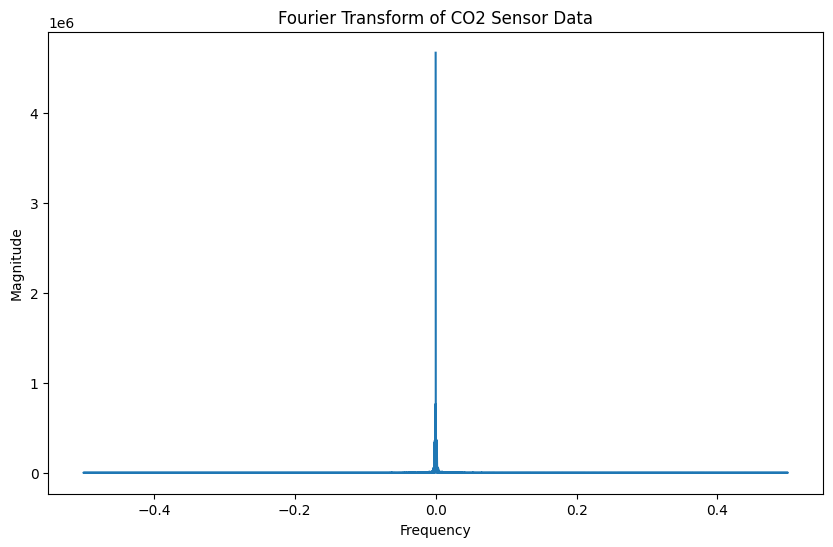

In [8]:
# Plot Fourier Transform result
plt.figure(figsize=(10, 6))
plt.plot(frequency, co2_fft)
plt.title("Fourier Transform of CO2 Sensor Data")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()

In [9]:
import pywt

In [10]:
# Select the Sound column for Wavelet analysis
sound_signal = X['S1_Sound'].values

In [11]:
# Apply Wavelet Transform to the Sound sensor data
def apply_wavelet_transform(signal, wavelet='db1', level=2):
 coeffs = pywt.wavedec(signal, wavelet, level=level)
 return coeffs
sound_wavelet_coeffs = apply_wavelet_transform(sound_signal, wavelet='db2', level=2)

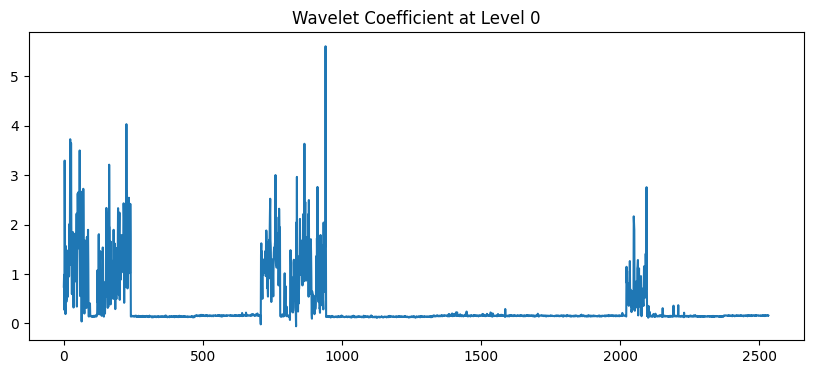

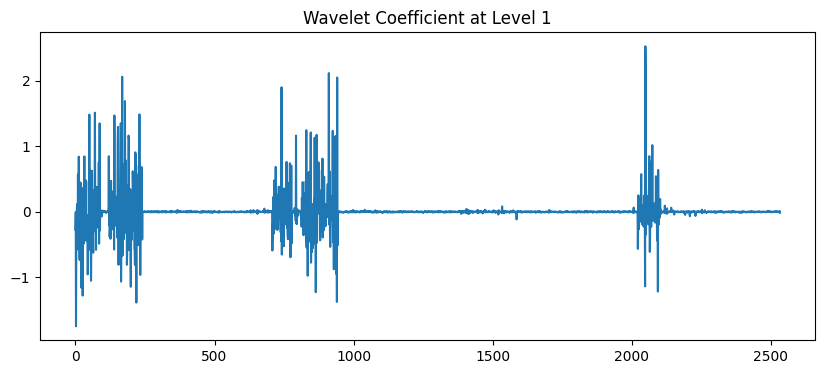

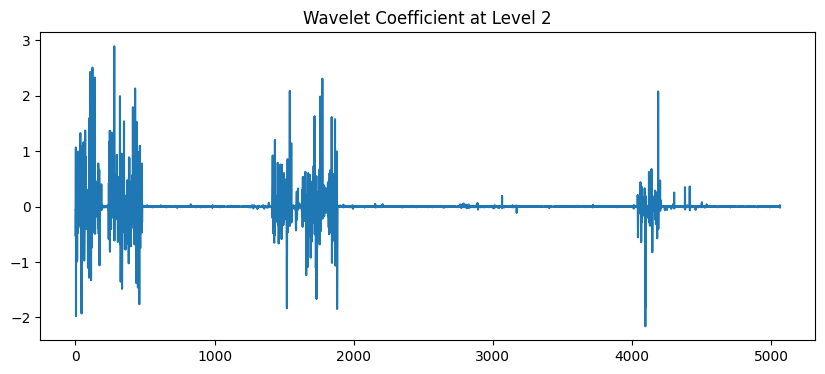

In [12]:
# Visualize the wavelet coefficients for interpretation
for i, coeff in enumerate(sound_wavelet_coeffs):
 plt.figure(figsize=(10, 4))
 plt.plot(coeff)
 plt.title(f"Wavelet Coefficient at Level {i}")
 plt.show()

In [13]:
# Feature selection

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# Load the Room Occupancy Estimation Dataset
data = pd.read_csv( r'C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 5\Occupancy_Estimation.csv')
print(data.columns)
X = data.drop('Room_Occupancy_Count', axis=1) # Separate features from target

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='object')


In [15]:
# Select only numeric columns
X_numeric = X.select_dtypes(include=['number'])
# Compute the correlation matrix for all numeric features
correlation_matrix = X_numeric.corr()

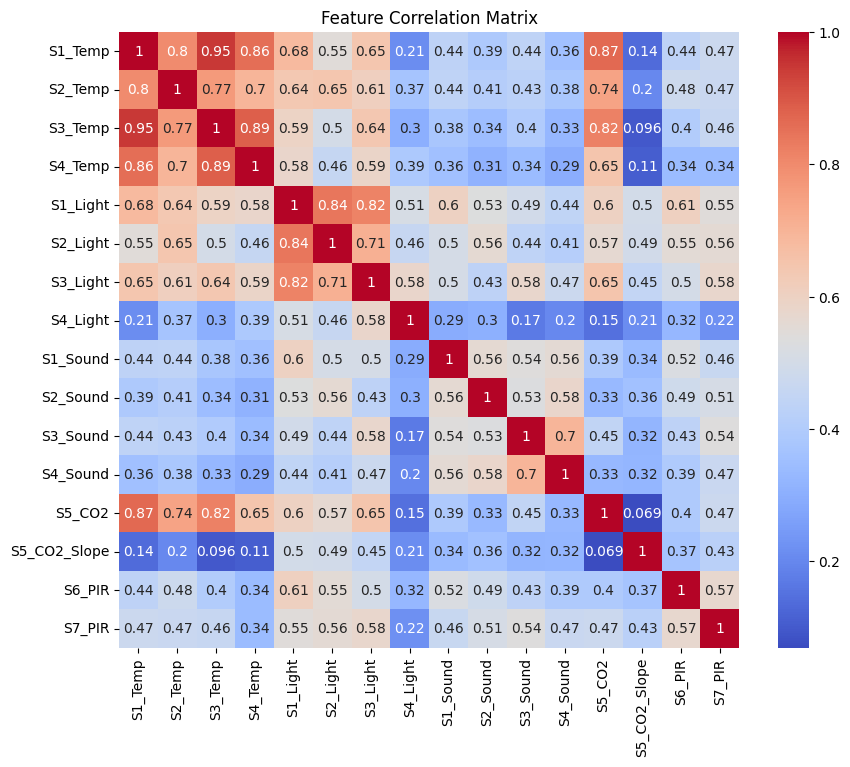

In [16]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [1]:
# Wrapper methods
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

In [4]:
data = pd.read_csv( r'C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 5\Occupancy_Estimation.csv')
print(data.columns)

# Step 2: Define the target variable and features
y = data['Room_Occupancy_Count'] # Target
X = data.drop('Room_Occupancy_Count', axis=1) # Features

# Filter for numeric columns only
X_numeric = X.select_dtypes(include=['number'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric) # Ensure X_numeric contains only numeric data

# Step 3: Instantiate a logistic regression model
model = LogisticRegression()

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='object')


In [5]:
# Select top 3 features using RFE
rfe = RFE(estimator=model, n_features_to_select=3)
rfe.fit(X_scaled, y)

# Identify selected features
selected_features_rfe = X_numeric.columns[rfe.support_]
print("Selected Features by RFE:", selected_features_rfe)

Selected Features by RFE: Index(['S3_Temp', 'S4_Temp', 'S1_Light'], dtype='object')


In [6]:
from sklearn.linear_model import Lasso

In [7]:
# Define the target variable and features
y = data['Room_Occupancy_Count'] # Target
X = data.drop('Room_Occupancy_Count', axis=1) # Features

# Filter for numeric columns only
X_numeric = X.select_dtypes(include=['number'])

# Standardize numeric features to improve Lasso performance
X_standardized = (X_numeric - X_numeric.mean()) / X_numeric.std()
y = data['Room_Occupancy_Count'].astype(float)

In [10]:
# Instantiate and fit Lasso
lasso = Lasso(alpha=0.3)
lasso.fit(X_standardized, y)

# Identify selected features
selected_features_lasso = X_numeric.columns[lasso.coef_ != 0]
print("Selected Features by Lasso:", selected_features_lasso)

Selected Features by Lasso: Index(['S1_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S7_PIR'], dtype='object')


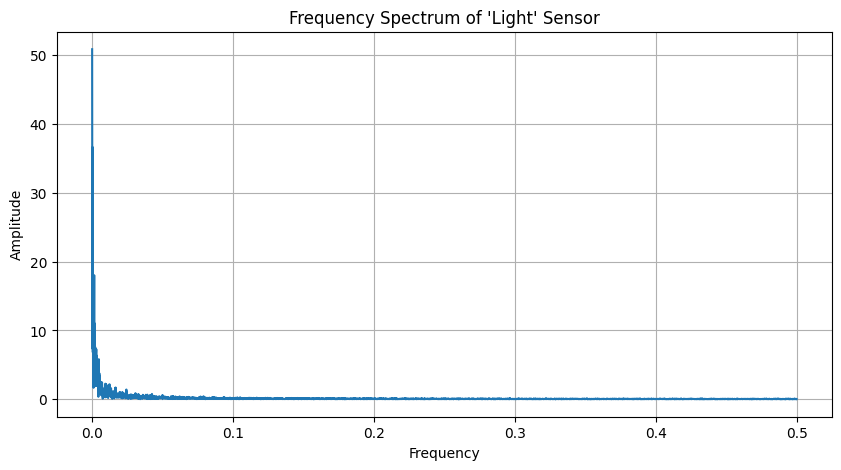

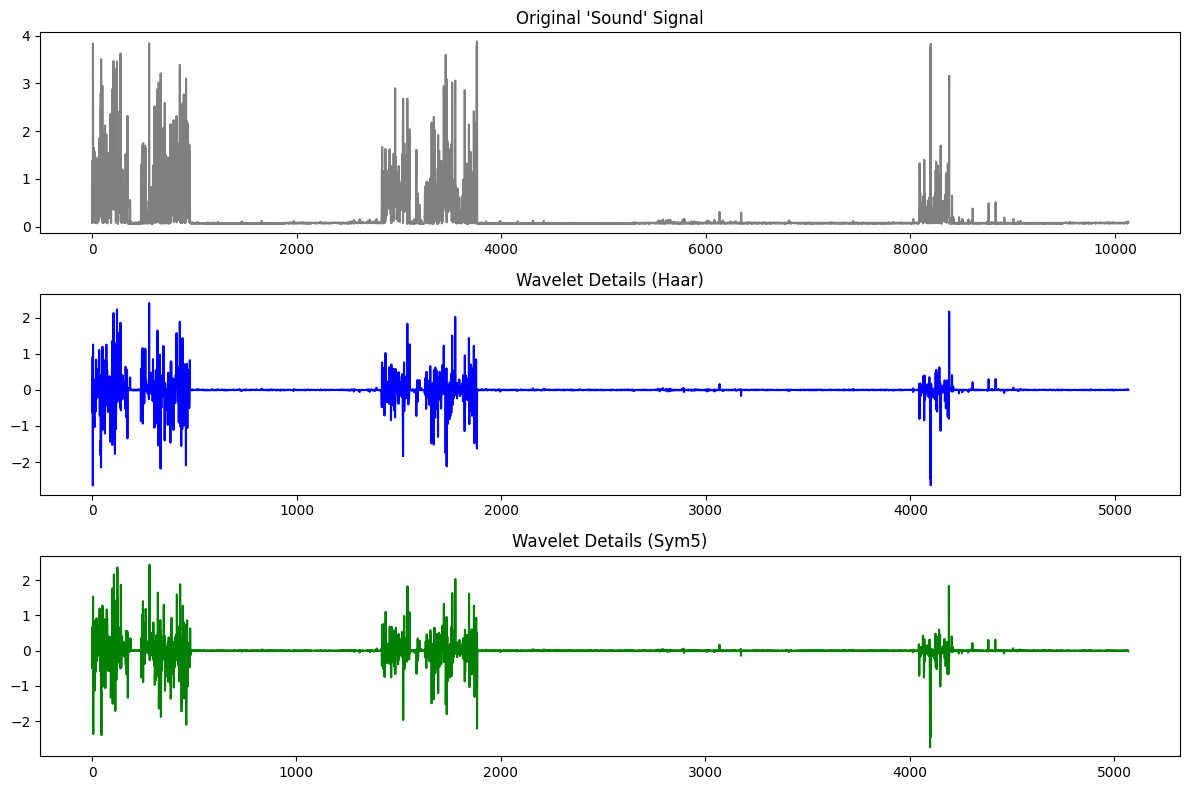


--- Smart Home Energy: Statistical Features ---
            Mean   Std Dev  Min  Max
Energy  2.548839  1.415526  0.1  5.0


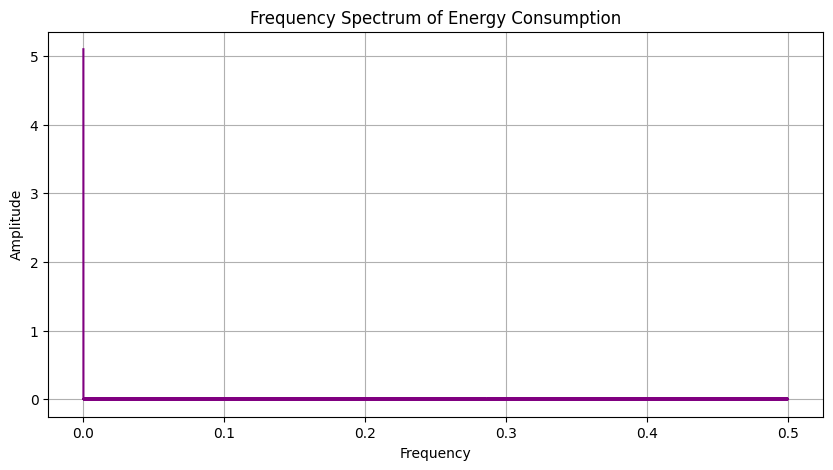

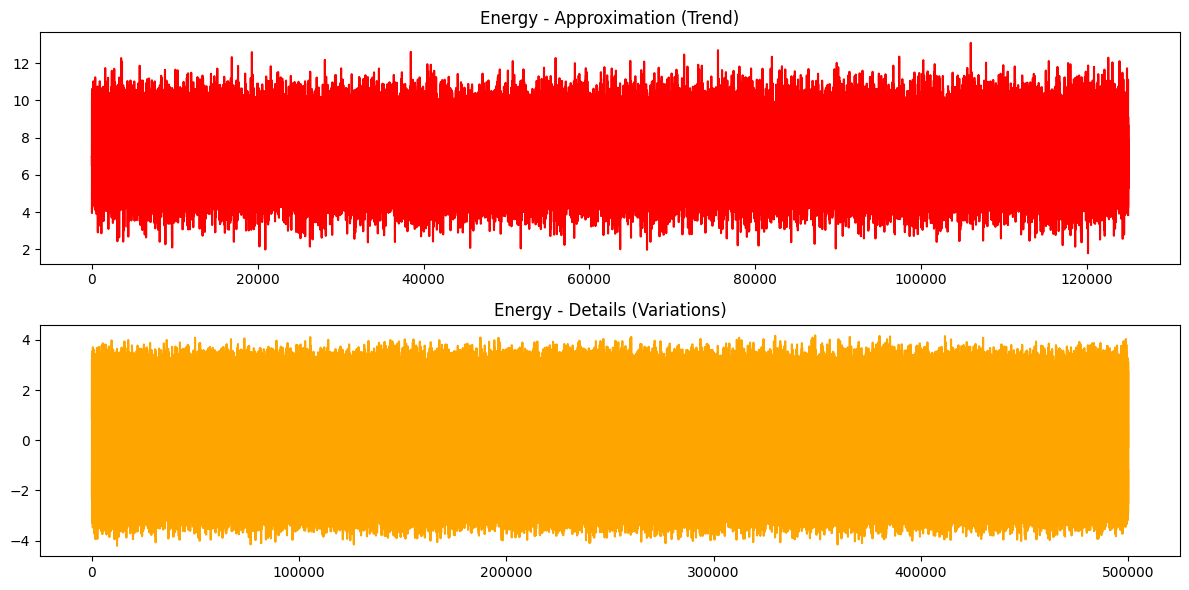

In [27]:
# Exercises

# 1.2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import pywt

df_occupancy = pd.read_csv(r'C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 5\Occupancy_Estimation.csv')

light_signal = df_occupancy['S1_Light'].values

N = len(light_signal)
T = 1.0  # Assumed sampling rate
yf = fft(light_signal)
xf = fftfreq(N, T)[:N//2]

plt.figure(figsize=(10, 5))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title("Frequency Spectrum of 'Light' Sensor")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# 1.3

sound_signal = df_occupancy['S1_Sound'].values

coeffs_haar = pywt.wavedec(sound_signal, 'haar', level=4)

coeffs_sym5 = pywt.wavedec(sound_signal, 'sym5', level=4)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(sound_signal, color='gray')
plt.title("Original 'Sound' Signal")

plt.subplot(3, 1, 2)
plt.plot(coeffs_haar[-1], color='blue')  # Plotting Level 1 details
plt.title("Wavelet Details (Haar)")

plt.subplot(3, 1, 3)
plt.plot(coeffs_sym5[-1], color='green') # Plotting Level 1 details
plt.title("Wavelet Details (Sym5)")

plt.tight_layout()
plt.show()

# 1.4

df_energy = pd.read_csv(r'C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 5\smart_home_energy_usage_dataset.csv')
energy_signal = df_energy['energy_consumption_kWh'].values

stats_features = {
    'Mean': np.mean(energy_signal),
    'Std Dev': np.std(energy_signal),
    'Min': np.min(energy_signal),
    'Max': np.max(energy_signal)
}
print("\n--- Smart Home Energy: Statistical Features ---")
print(pd.DataFrame(stats_features, index=['Energy']))

N_energy = len(energy_signal)
yf_energy = fft(energy_signal)
xf_energy = fftfreq(N_energy, 1)[:N_energy//2]

plt.figure(figsize=(10, 5))
plt.plot(xf_energy, 2.0/N_energy * np.abs(yf_energy[0:N_energy//2]), color='purple')
plt.title("Frequency Spectrum of Energy Consumption")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

coeffs_energy = pywt.wavedec(energy_signal, 'db4', level=3)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(coeffs_energy[0], color='red')
plt.title("Energy - Approximation (Trend)")

plt.subplot(2, 1, 2)
plt.plot(coeffs_energy[-1], color='orange')
plt.title("Energy - Details (Variations)")

plt.tight_layout()
plt.show()

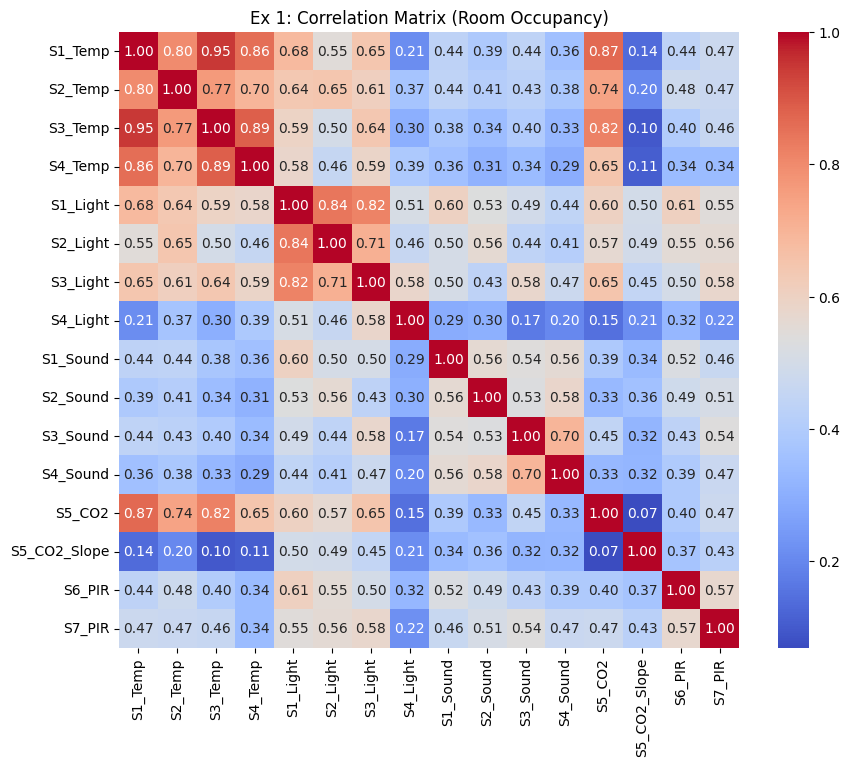

Highly Correlated Pairs (> 0.9): [('S1_Temp', 'S3_Temp')]
Features removed: {'S3_Temp'}
Accuracy (Full Set): 0.9926
Accuracy (Reduced Set): 0.9891
Top 3 Features by RFE: ['S3_Temp', 'S4_Temp', 'S1_Light']
Accuracy (RFE Selected): 0.9324
Features Selected by Lasso: ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR']
Comparison with RFE: Matches


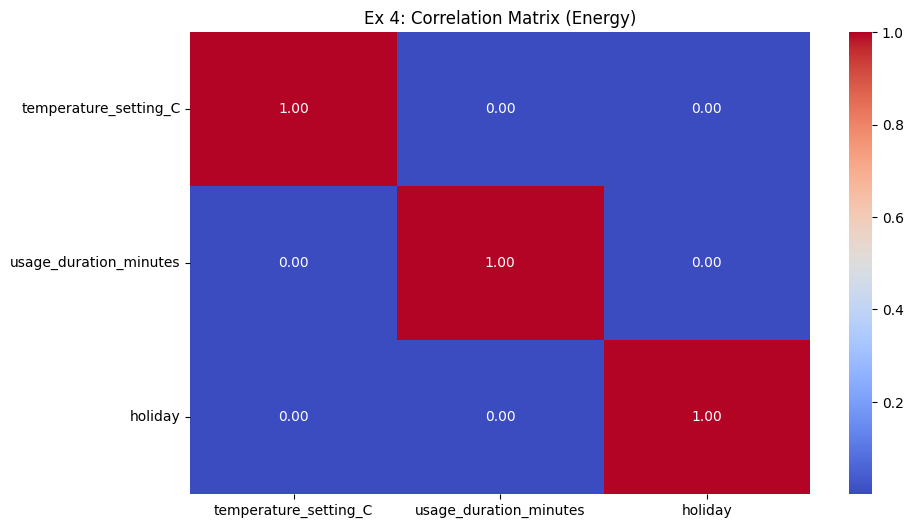

C:\Program Files\Python313\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


Top 5 Features by RFE: ['temperature_setting_C', 'usage_duration_minutes', 'holiday']
Features Selected by Lasso: []


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

y = df_occupancy['Room_Occupancy_Count']
X = df_occupancy.drop(['Room_Occupancy_Count', 'Date', 'Time'], axis=1) # Drop non-numeric

X_numeric = X.select_dtypes(include=['number'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2.1

corr_matrix = X_numeric.corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ex 1: Correlation Matrix (Room Occupancy)")
plt.show()

high_corr_var = np.where(corr_matrix > 0.9)
high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y]) 
                   for x, y in zip(*high_corr_var) if x != y and x < y]

print("Highly Correlated Pairs (> 0.9):", high_corr_pairs)

features_to_remove = set([pair[1] for pair in high_corr_pairs])
X_train_reduced = X_train.drop(columns=features_to_remove)
X_test_reduced = X_test.drop(columns=features_to_remove)

print(f"Features removed: {features_to_remove}")

model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

model_reduced = LogisticRegression(max_iter=1000)
model_reduced.fit(X_train_reduced, y_train)
acc_reduced = accuracy_score(y_test, model_reduced.predict(X_test_reduced))

print(f"Accuracy (Full Set): {acc_full:.4f}")
print(f"Accuracy (Reduced Set): {acc_reduced:.4f}")


# 2.2

model_rfe = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model_rfe, n_features_to_select=3)
rfe.fit(X_train, y_train)

selected_features_rfe = X_numeric.columns[rfe.support_]
print("Top 3 Features by RFE:", list(selected_features_rfe))

X_train_rfe = X_train[selected_features_rfe]
X_test_rfe = X_test[selected_features_rfe]

model_rfe_final = LogisticRegression(max_iter=1000)
model_rfe_final.fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, model_rfe_final.predict(X_test_rfe))

print(f"Accuracy (RFE Selected): {acc_rfe:.4f}")


# 2.3

lasso = Lasso(alpha=0.01) # Small alpha to not zero out everything
lasso.fit(X_train, y_train.astype(float))

selected_features_lasso = X_numeric.columns[lasso.coef_ != 0]
print("Features Selected by Lasso:", list(selected_features_lasso))
print("Comparison with RFE:", "Matches" if set(selected_features_rfe).issubset(set(selected_features_lasso)) else "Different")


# 2.4

y_energy = df_energy['energy_consumption_kWh']
X_energy = df_energy.drop(['energy_consumption_kWh', 'timestamp', 'home_id'], axis=1)
X_energy_numeric = X_energy.select_dtypes(include=['number'])

scaler_energy = StandardScaler()
X_energy_scaled = pd.DataFrame(scaler_energy.fit_transform(X_energy_numeric), columns=X_energy_numeric.columns)

corr_matrix_energy = X_energy_numeric.corr().abs()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix_energy, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ex 4: Correlation Matrix (Energy)")
plt.show()

model_lin = LinearRegression()
rfe_energy = RFE(estimator=model_lin, n_features_to_select=5)
rfe_energy.fit(X_energy_scaled, y_energy)

selected_rfe_energy = X_energy_numeric.columns[rfe_energy.support_]
print("Top 5 Features by RFE:", list(selected_rfe_energy))

lasso_energy = Lasso(alpha=0.01)
lasso_energy.fit(X_energy_scaled, y_energy)

selected_lasso_energy = X_energy_numeric.columns[lasso_energy.coef_ != 0]
print("Features Selected by Lasso:", list(selected_lasso_energy))